In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix, classification_report

In [83]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [84]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [85]:
df = df[['TotalWorkingYears', 'MonthlyIncome', 'JobSatisfaction',
         'Age', 'DistanceFromHome', 'YearsAtCompany', 'Attrition']]

In [86]:
df.dropna(inplace=True)

In [87]:
print("Attrition Distribution:\n", df['Attrition'].value_counts())

Attrition Distribution:
 Attrition
0    1233
1     237
Name: count, dtype: int64


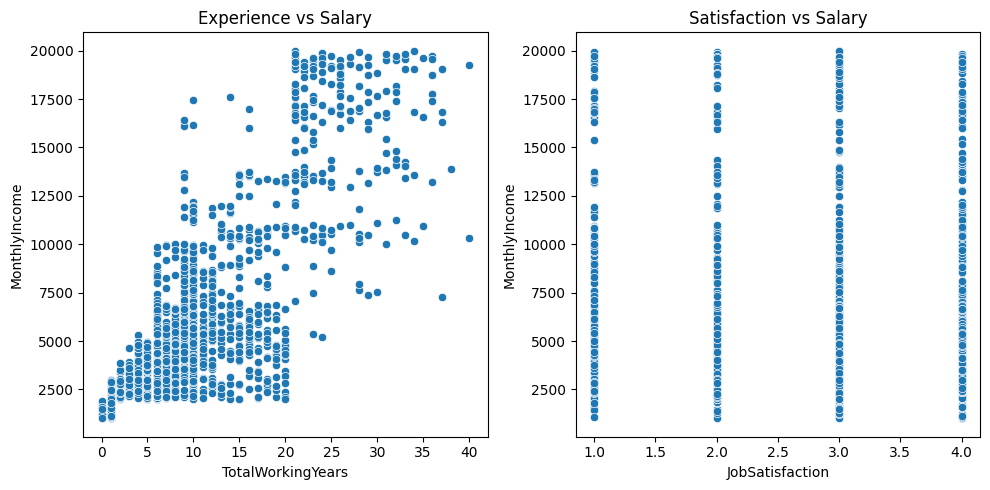

In [88]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.scatterplot(x='TotalWorkingYears', y='MonthlyIncome', data=df)
plt.title("Experience vs Salary")

plt.subplot(1,2,2)
sns.scatterplot(x='JobSatisfaction', y='MonthlyIncome', data=df)
plt.title("Satisfaction vs Salary")

plt.tight_layout()
plt.show()

**LINEAR REGRESSION (Salary Prediction)**


In [89]:
X_reg = df[['TotalWorkingYears', 'JobSatisfaction']]
y_reg = df['MonthlyIncome']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

model_reg = LinearRegression()
model_reg.fit(X_train_reg, y_train_reg)

y_pred_reg = model_reg.predict(X_test_reg)

print("\nMAE :", mean_absolute_error(y_test_reg, y_pred_reg))


MAE : 2233.833860729943


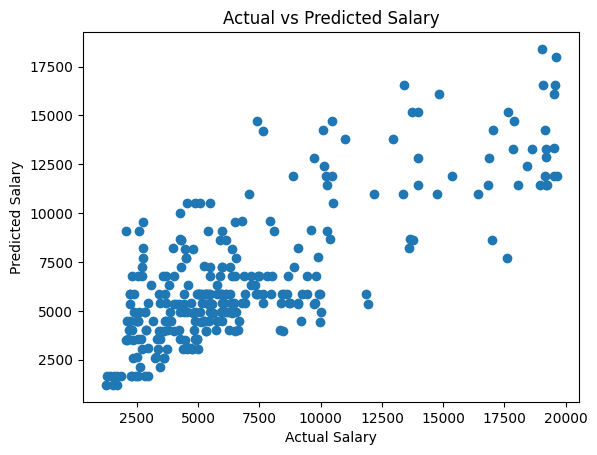

In [90]:
plt.scatter(y_test_reg, y_pred_reg)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

**RANDOM FOREST (Attrition Prediction)**

In [91]:
X_cls = df[['TotalWorkingYears', 'MonthlyIncome', 'JobSatisfaction',
            'Age', 'DistanceFromHome', 'YearsAtCompany']]

y_cls = df['Attrition']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_cls, y_train_cls)

y_pred_rf = model_rf.predict(X_test_cls)

print("\n Accuracy:", accuracy_score(y_test_cls, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test_cls, y_pred_rf))


 Accuracy: 0.8673469387755102

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.50      0.13      0.20        39

    accuracy                           0.87       294
   macro avg       0.69      0.55      0.57       294
weighted avg       0.83      0.87      0.83       294



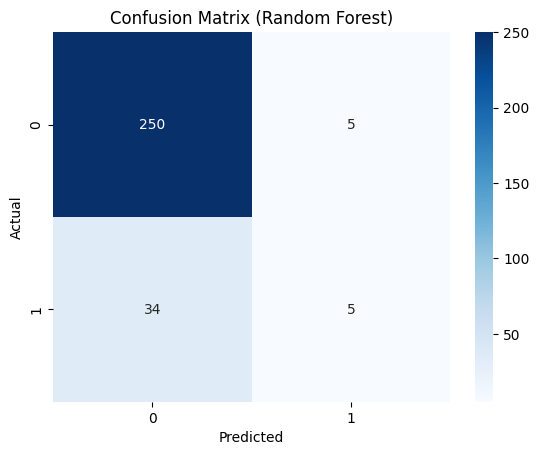

In [92]:
cm = confusion_matrix(y_test_cls, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()